🔍 Detected 5 high-prominence peaks.

📏 Calibration Diagnostics:
   ✅ LINEAR SCAN: Peak spacing is uniform (Max deviation: 6.5%).
   -> Applying standard linear calibration.


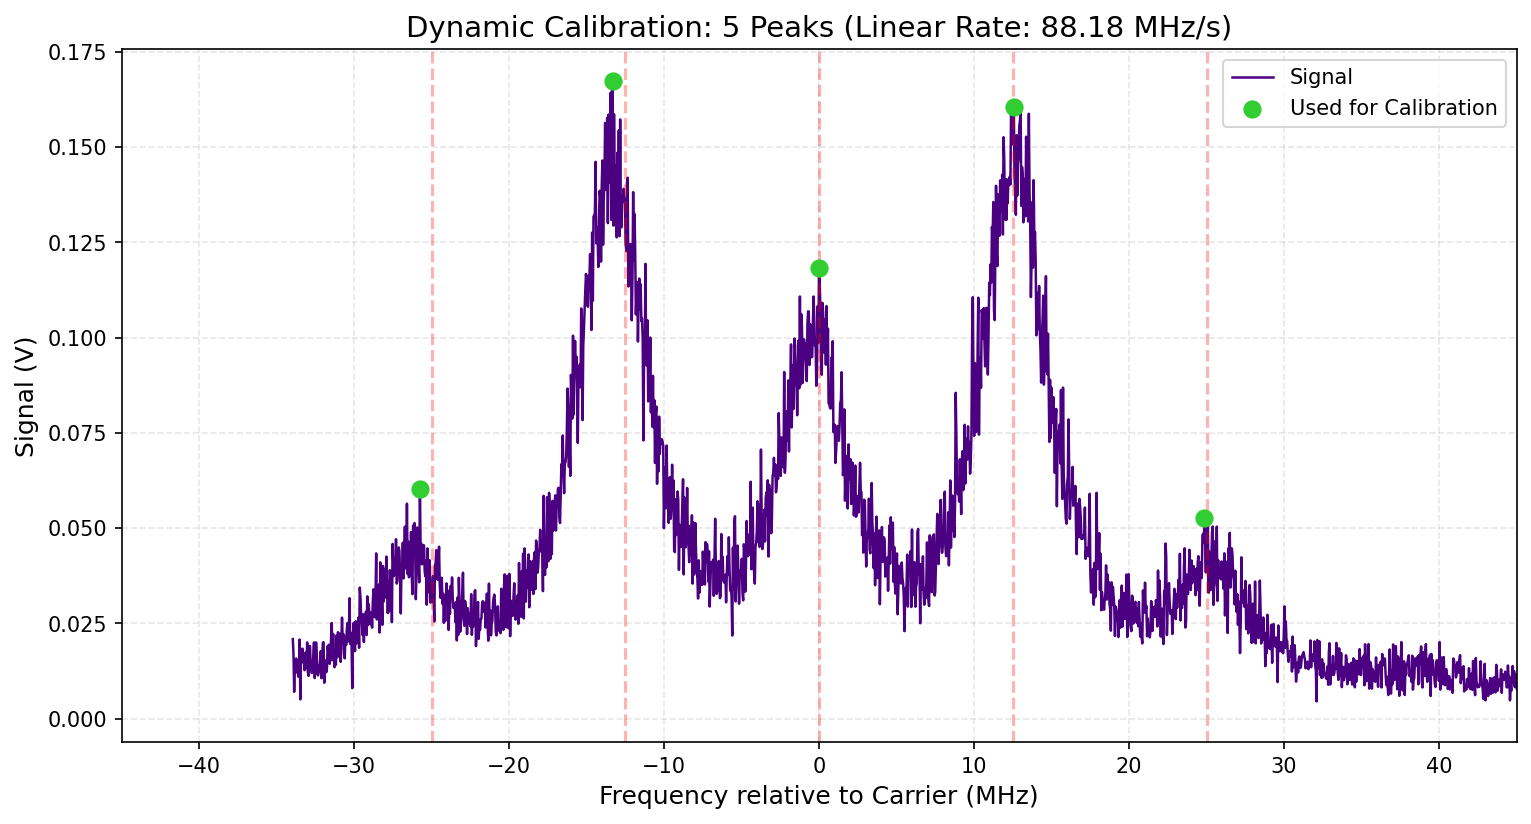

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from pathlib import Path

# --- LOAD DATA ---
data_dir = Path("/Users/michelangelodondi/Documents/Research/rb6s-spectroscopy/data/01_raw/power_eom")
f = data_dir / "4121nm_eom_after1.csv"
df = pd.read_csv(f, skiprows=2, header=None)
df.columns = ['time_s', 'signal_v']
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# --- DYNAMIC PEAK DETECTION ---
peaks, props = find_peaks(df['signal_v'], prominence=0.03, distance=50)
t_peaks = np.sort(df['time_s'].iloc[peaks].values)
v_peaks = np.sort(df['signal_v'].iloc[peaks].values)

num_peaks = len(t_peaks)
print(f"🔍 Detected {num_peaks} high-prominence peaks.")

if num_peaks >= 3:
    # 1. Identify the Carrier (Assume it's the middle peak of the cluster)
    center_idx = num_peaks // 2
    t_carrier = t_peaks[center_idx]
    
    # 2. Assign Theoretical Frequencies (Assuming 12.5 MHz spacing)
    # E.g., if 5 peaks, indices are -2, -1, 0, 1, 2 -> multiplied by 12.5
    peak_indices = np.arange(num_peaks) - center_idx
    expected_freqs = peak_indices * 12.5
    
    # 3. The Interval Test (Check for piezo linearity)
    spacings = np.diff(t_peaks)
    avg_spacing = np.median(spacings)
    max_deviation = np.max(np.abs(spacings - avg_spacing)) / avg_spacing
    
    print("\n📏 Calibration Diagnostics:")
    if max_deviation > 0.10:
        print(f"   ⚠️ PIEZO WARPING DETECTED: Peak spacing varies by {max_deviation*100:.1f}%.")
        print("   -> Applying 2nd-Order Polynomial Correction to unwarp the scan.")
        # Fit a curve: Time -> Frequency to account for non-linear scanning
        fit_coeffs = np.polyfit(t_peaks, expected_freqs, 2)
        # Apply the quadratic fit to the whole time axis
        df['freq_mhz'] = np.polyval(fit_coeffs, df['time_s'])
        scan_rate_msg = "Non-Linear Fit Applied"
    else:
        print(f"   ✅ LINEAR SCAN: Peak spacing is uniform (Max deviation: {max_deviation*100:.1f}%).")
        print("   -> Applying standard linear calibration.")
        mhz_per_s = 12.5 / avg_spacing
        df['freq_mhz'] = (df['time_s'] - t_carrier) * mhz_per_s
        scan_rate_msg = f"Linear Rate: {mhz_per_s:.2f} MHz/s"

    # --- PLOTTING ---
    plt.figure(figsize=(12, 6), dpi=150)
    plt.plot(df['freq_mhz'], df['signal_v'], color='indigo', linewidth=1.2, label='Signal')
    
    # Plot the peaks we detected
    detected_freqs = df['freq_mhz'].iloc[peaks].values
    plt.scatter(detected_freqs, df['signal_v'].iloc[peaks], color='limegreen', zorder=5, s=60, label='Used for Calibration')

    # Draw the theoretical grid based on the assigned frequencies
    for freq in expected_freqs:
        plt.axvline(freq, color='red', linestyle='--', alpha=0.3)

    plt.title(f"Dynamic Calibration: {num_peaks} Peaks ({scan_rate_msg})", fontsize=14)
    plt.xlabel("Frequency relative to Carrier (MHz)", fontsize=12)
    plt.ylabel("Signal (V)", fontsize=12)
    
    # Auto-scale the X-axis to fit the peaks we found + a little padding
    plt.xlim(expected_freqs[0] - 20, expected_freqs[-1] + 20)
    
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend()
    plt.show()

else:
    print(f"❌ Critical Failure: Only found {num_peaks} peaks. Need at least 3 (Carrier + 2 Sidebands) to calibrate.")
    print("Action required: Decrease 'prominence' or check the raw data plot for missing sidebands.")